In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
from tqdm import tqdm
from scipy.signal import convolve2d
from scipy.signal import max_len_seq
import numpy as np
import pyntbci
sns.set_style('whitegrid')

random.seed(42)
np.random.seed(42)

In [33]:
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 12,
    'axes.labelsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
})

# Visualize codes for each condition

In [34]:
objects = {
    0: 'can', 
    1: 'bandage', 
    2: 'remote', 
    3: 'bottle', 
    4: 'candle', 
    5: 'box', 
    6: 'book', 
    7: 'cup'
}

## Kolkhorst

In [35]:
target_id = 4

codebook = np.load(f'./condition_1/codebook_obj_{target_id}.npy')

codebook_extended = []
for code in codebook:
    tmp = []
    for i in code:
        if i == 0:
            tmp += [0] * 250
        elif i == 1:
            tmp += [1] * 100
            tmp += [0] * 150
    codebook_extended.append(tmp)
codebook_extended = np.array(codebook_extended)
codebook_extended.shape

(8, 24000)

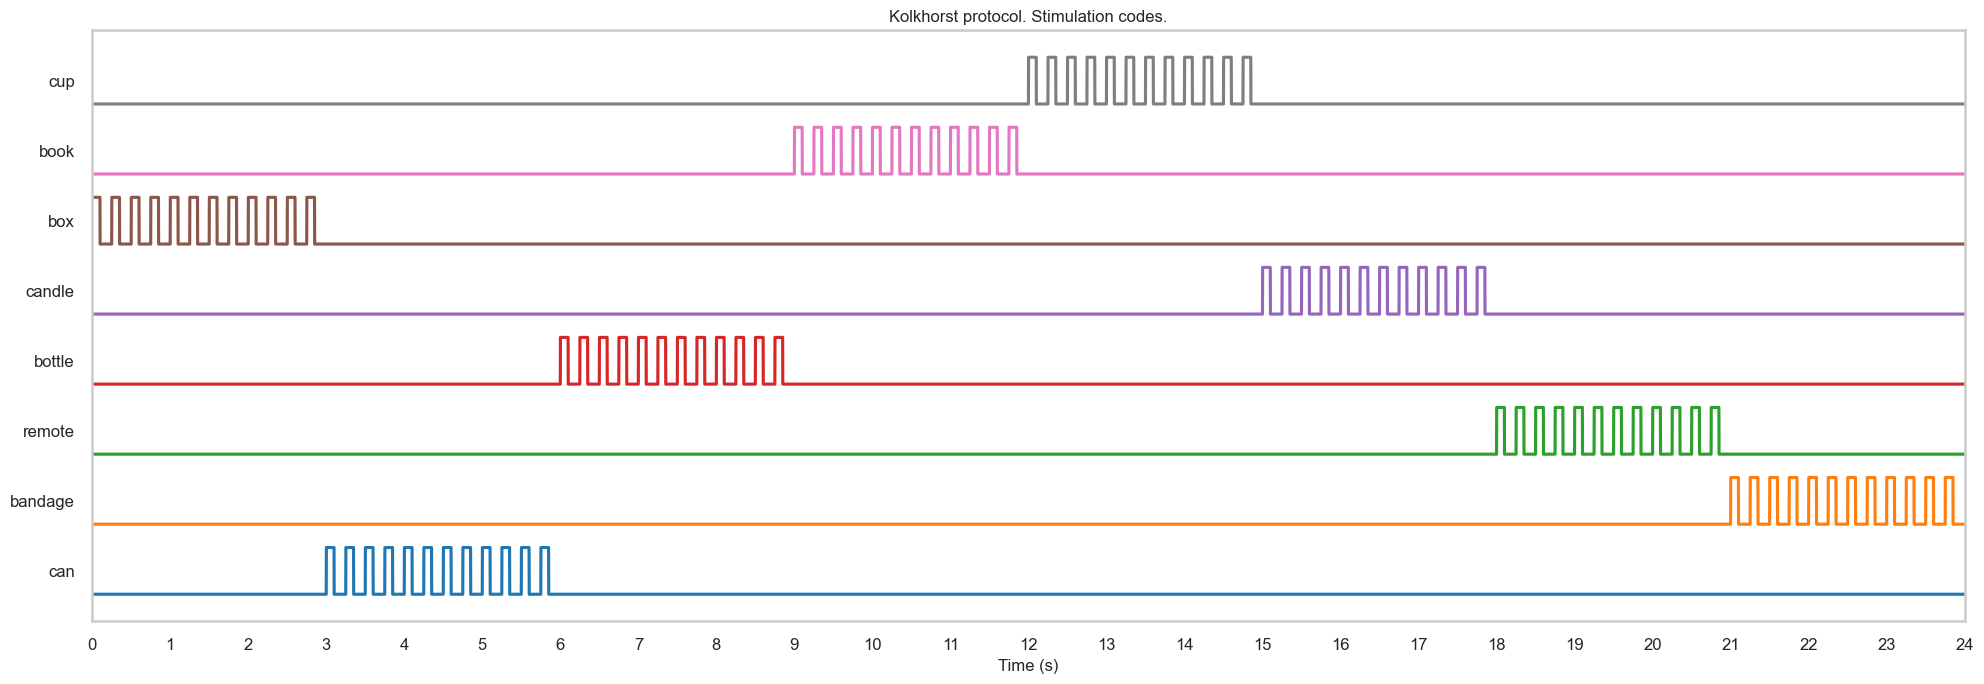

In [36]:
spacing = 1.5  # Adjust this value to increase/decrease spacing
plt.figure(figsize=(20, 7))

for i, code in enumerate(codebook_extended):
    xticks = np.arange(len(code)) / 1000
    plt.plot(xticks, code + i * spacing)
plt.title('Kolkhorst protocol. Stimulation codes.')
plt.xlabel('Time (s)')
plt.yticks(np.arange(8) * spacing + 0.5, objects.values())
plt.xticks(np.arange(25))
plt.xlim(0, 24)
plt.tight_layout()
plt.grid()
plt.savefig('../images/kolkhorst_code_extended.png')
plt.show()

## Fast ERP

In [37]:
codebook = np.load('./condition_2/codebook_obj_0.npy')

codebook_extended = []
for code in codebook:
    tmp = []
    for i in code:
        if i == 0:
            tmp += [0] * 250
        elif i == 1:
            tmp += [1] * 100
            tmp += [0] * 150
    codebook_extended.append(tmp)
codebook_extended = np.array(codebook_extended)

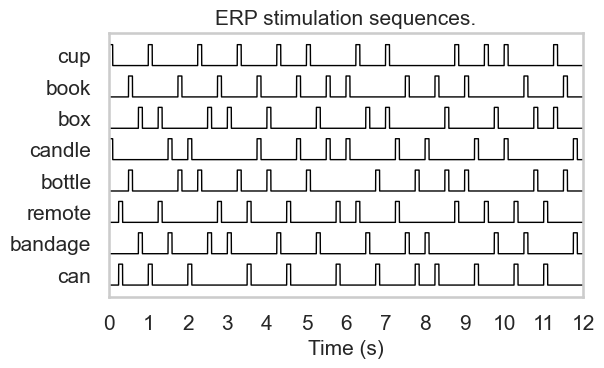

In [50]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np



spacing = 1.5
n = len(codebook_extended)
scaling = 2
font_scaling = 1.5
width_cm = 8*scaling
height_cm = 5*scaling  # try 7.5–9.5 depending on label length

mpl.rcParams.update({
    "font.size": 10 * font_scaling,
    "axes.titlesize": 10 * font_scaling,
    "axes.labelsize": 10 * font_scaling,
    "xtick.labelsize": 10 * font_scaling,
    "ytick.labelsize": 10 * font_scaling,
})

fig, ax = plt.subplots(figsize=(width_cm/2.54, height_cm/2.54))

for i, code in enumerate(codebook_extended):
    xticks = np.arange(len(code)) / 1000
    ax.plot(xticks, code + i * spacing, color="black", linewidth=1)

ax.set_title("ERP stimulation sequences.")
ax.set_xlabel("Time (s)")
ax.set_xlim(0, 12)
ax.set_xticks(np.arange(13))

ax.set_yticks(np.arange(n) * spacing + 0.5)
ax.set_yticklabels(list(objects.values()))

ax.grid()
fig.tight_layout()

fig.savefig("../images/fasterp_code_extended.eps", bbox_inches="tight")
plt.show()